# S16 – Диффузионные модели: от идеи к базовой генерации изображений

В этом ноутбуке закрываем 16-й семинар более широкой мультимодальной картиной:  
после **CLIP retrieval** переходим к **диффузионным моделям**, которые не ищут готовое изображение,  
а **синтезируют новое** по текстовому условию.

Главная идея такая:

1. понимаем на интуитивном уровне, что такое процесс добавления шума и обратного денойзинга;
2. смотрим, где диффузия находится среди других мультимодальных подходов;
3. загружаем готовый `text-to-image` pipeline;
4. генерируем несколько изображений по текстовым запросам;
5. изучаем, как prompt и параметры влияют на результат;
6. обсуждаем ограничения, риски и инженерные компромиссы.

Важно: это **обзорно-практический** ноутбук.  
Наша цель здесь – не обучать diffusion-модель с нуля, а понять,  
как выглядит её использование на практике и чем она отличается от retrieval-подходов вроде CLIP.


## 0. План

К концу ноутбука надо уметь:

1. Объяснять интуитивную идею диффузионных моделей.
2. Показывать прямой и обратный процесс на упрощённом визуальном примере.
3. Загружать готовый `text-to-image` diffusion pipeline.
4. Генерировать изображения по коротким текстовым запросам.
5. Сравнивать влияние prompt, `guidance_scale` и `num_inference_steps`.
6. Понимать различие между retrieval и generation.
7. Видеть ограничения и риски генеративной мультимодальности.


## 1. Импорты и общие настройки

Ниже подключаем библиотеки, фиксируем `seed`, выбираем устройство и настраиваем вывод.

> Для генеративной части дополнительно нужен пакет `diffusers`.  
> Если он не установлен, соответствующие ячейки просто сообщат об этом и пропустят запуск генерации.


In [1]:

# Базовые библиотеки для визуализации, шумовых примеров и diffusion pipeline.
import os
import random
from pathlib import Path
from typing import List, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from PIL import Image
from torchvision.datasets import CIFAR10

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 220)
pd.set_option("display.precision", 4)

os.environ["TOKENIZERS_PARALLELISM"] = "false"

try:
    from diffusers import StableDiffusionPipeline
    DIFFUSERS_AVAILABLE = True
except Exception:
    StableDiffusionPipeline = None
    DIFFUSERS_AVAILABLE = False

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Diffusers available:", DIFFUSERS_AVAILABLE)


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Torch: 2.10.0+cu128
CUDA available: True
Diffusers available: True


In [2]:

# Фиксируем seed и определяем устройство.
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Устройство:", DEVICE)


Устройство: cuda


## 2. Что такое диффузионная модель на интуитивном уровне

Идея диффузии очень грубо выглядит так:

- **прямой процесс**: к изображению постепенно добавляется шум;
- **обратный процесс**: модель учится по шумной картинке восстанавливать более чистую версию;
- если запускать обратный процесс от случайного шума и давать текстовое условие,  
  можно постепенно получить новое изображение, согласованное с prompt.

Ниже покажем упрощённую визуализацию прямого процесса:  
возьмём картинку и будем добавлять к ней всё больше случайного шума.


100%|██████████| 170M/170M [00:05<00:00, 32.1MB/s]


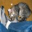

In [3]:

CIFAR_ROOT = Path("data")
cifar_test = CIFAR10(root=CIFAR_ROOT, train=False, download=True)

sample_image = None
for image, label_id in cifar_test:
    if cifar_test.classes[label_id] == "cat":
        sample_image = image.convert("RGB")
        break

if sample_image is None:
    raise RuntimeError("Не удалось найти пример изображения для визуализации.")

sample_image


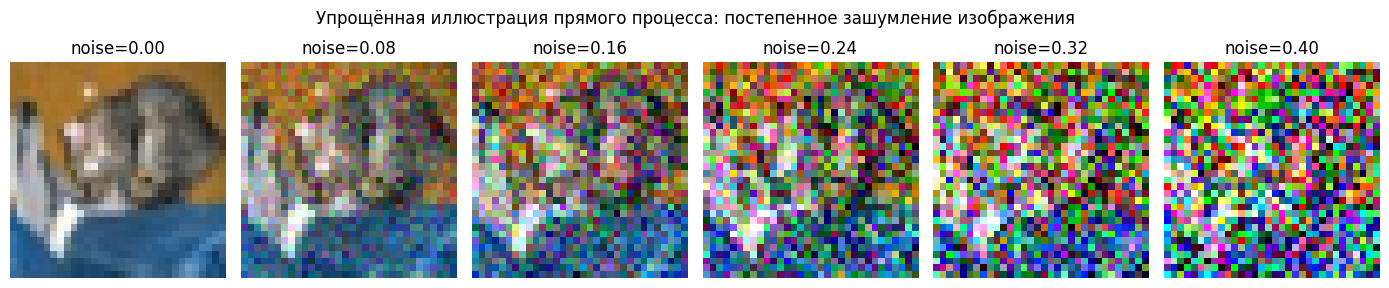

In [4]:

def add_gaussian_noise(image: Image.Image, noise_level: float) -> Image.Image:
    array = np.asarray(image).astype(np.float32) / 255.0
    noise = np.random.normal(loc=0.0, scale=noise_level, size=array.shape)
    noisy = np.clip(array + noise, 0.0, 1.0)
    noisy_uint8 = (255 * noisy).astype(np.uint8)
    return Image.fromarray(noisy_uint8)


noise_levels = [0.0, 0.08, 0.16, 0.24, 0.32, 0.40]
noisy_images = [add_gaussian_noise(sample_image, level) for level in noise_levels]

plt.figure(figsize=(14, 3))
for idx, (img, level) in enumerate(zip(noisy_images, noise_levels), start=1):
    ax = plt.subplot(1, len(noisy_images), idx)
    ax.imshow(img)
    ax.set_title(f"noise={level:.2f}")
    ax.axis("off")

plt.suptitle("Упрощённая иллюстрация прямого процесса: постепенное зашумление изображения")
plt.tight_layout()
plt.show()


## 3. Где диффузия находится среди других мультимодальных подходов

После двух предыдущих ноутбуков полезно явно развести две логики:

**CLIP / retrieval-подход**

- у нас уже есть коллекция изображений;
- мы ищем наиболее подходящее изображение по тексту;
- результат – это **выбор из существующих объектов**.

**Diffusion / generation-подход**

- мы не ищем готовое изображение;
- модель синтезирует **новый объект**;
- результат зависит от prompt, случайного шума и параметров генерации.

То есть retrieval отвечает на вопрос  
**«что в моей базе больше всего похоже на этот запрос?»**,  
а generation – на вопрос  
**«сгенерируй новый пример, удовлетворяющий этому описанию»**.


## 4. Загрузка готового `text-to-image` pipeline

Для демонстрации используем специальный **тестовый** pipeline –  
`hf-internal-testing/tiny-stable-diffusion-pipe`.

Важно понять, что это за модель:

- создана исключительно для тестирования кода библиотеки `diffusers`;
- её веса **случайные, не обученные** ни на каком наборе данных;
- поэтому вывод будет выглядеть как случайный шум – это **ожидаемое** поведение.

Мы используем именно её, потому что:

- скачивается быстро (несколько мегабайт);
- не требует мощной GPU;
- позволяет изучить устройство и API pipeline без ожидания тяжёлой загрузки.

> **Для получения визуально осмысленных изображений** нужна настоящая модель  
> (например, `stable-diffusion-v1-5`, `SDXL` и им подобные).  
> Они требуют от 4 до 8 ГБ VRAM и занимают несколько гигабайт на диске.  
> Именно это и есть тот инфраструктурный порог, который важно осознавать.

Ниже предусмотрен мягкий fallback: если `diffusers` или модель недоступны,  
ячейка не падает, а просто сообщает, что генеративную часть нужно пропустить.


In [5]:

PIPELINE_MODEL_NAME = "hf-internal-testing/tiny-stable-diffusion-pipe"
#PIPELINE_MODEL_NAME = "stable-diffusion-v1-5/stable-diffusion-v1-5"

pipe: Optional[StableDiffusionPipeline] = None

if DIFFUSERS_AVAILABLE:
    try:
        dtype = torch.float16 if DEVICE == "cuda" else torch.float32

        pipe = StableDiffusionPipeline.from_pretrained(
            PIPELINE_MODEL_NAME,
            torch_dtype=dtype,
            # Safety checker требует отдельного CLIP-ViT; для учебной тестовой
            # модели он не нужен и только занимает VRAM.
            safety_checker=None,
            requires_safety_checker=False,
        )
        pipe = pipe.to(DEVICE)

        # Снижаем пиковое потребление памяти при денойзинге.
        pipe.enable_attention_slicing()
        pipe.set_progress_bar_config(disable=True)
        print("Загружен pipeline:", PIPELINE_MODEL_NAME)
    except Exception as exc:
        print("Не удалось загрузить diffusion pipeline.")
        print(type(exc).__name__, str(exc)[:300])
        pipe = None
else:
    print("Пакет diffusers не установлен – генеративная часть будет пропущена.")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/566 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--hf-internal-testing--tiny-stable-diffusion-pipe/snapshots/3ee6c9f225f088ad5d35b624b6514b091e6a4849/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--hf-internal-testing--tiny-stable-diffusion-pipe/snapshots/3ee6c9f225f088ad5d35b624b6514b091e6a4849/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading weights:   0%|          | 0/84 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--hf-internal-testing--tiny-stable-diffusion-pipe/snapshots/3ee6c9f225f088ad5d35b624b6514b091e6a4849/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--hf-internal-testing--tiny-stable-diffusion-pipe/snapshots/3ee6c9f225f088ad5d35b624b6514b091e6a4849/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--hf-internal-testing--tiny-stable-diffusion-pipe/snapshots/3ee6c9f225f088ad5d35b624b6514b091e6a4849/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Загружен pipeline: hf-internal-testing/tiny-stable-diffusion-pipe


In [6]:

def generate_image(
    prompt: str,
    negative_prompt: Optional[str] = None,
    guidance_scale: float = 7.5,
    num_inference_steps: int = 25,
    seed: int = 42,
) -> Optional[Image.Image]:
    if pipe is None:
        print("Pipeline недоступен, генерация пропущена.")
        return None

    generator = torch.Generator(device=DEVICE).manual_seed(seed)

    result = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        guidance_scale=guidance_scale,
        num_inference_steps=num_inference_steps,
        generator=generator,
    )

    return result.images[0]


## 5. Базовая text-to-image генерация

Попробуем несколько коротких запросов и посмотрим, как выглядит вызов pipeline.

Поскольку тестовая модель имеет случайные веса, все выходные изображения будут выглядеть  
как цветной шум – это нормально и не является ошибкой.  
Нас здесь интересует **механика вызова**, а не визуальное качество:

- один prompt → одна генерация с зафиксированным `seed`;
- меняем prompt → меняется начальный шум, форма шума другая, но осмысленного содержания нет;
- настоящая модель при тех же вызовах давала бы содержательную картинку.


In [7]:

basic_prompts = [
    "a watercolor illustration of a red fox in snow",
    "a small robot vacuum cleaner in a modern apartment",
    "a sailing ship at sunset, digital art",
]

generated_images: List[Optional[Image.Image]] = []
for prompt in basic_prompts:
    print("PROMPT:", prompt)
    generated_images.append(generate_image(prompt=prompt, num_inference_steps=20, guidance_scale=7.0, seed=42))


PROMPT: a watercolor illustration of a red fox in snow
PROMPT: a small robot vacuum cleaner in a modern apartment
PROMPT: a sailing ship at sunset, digital art


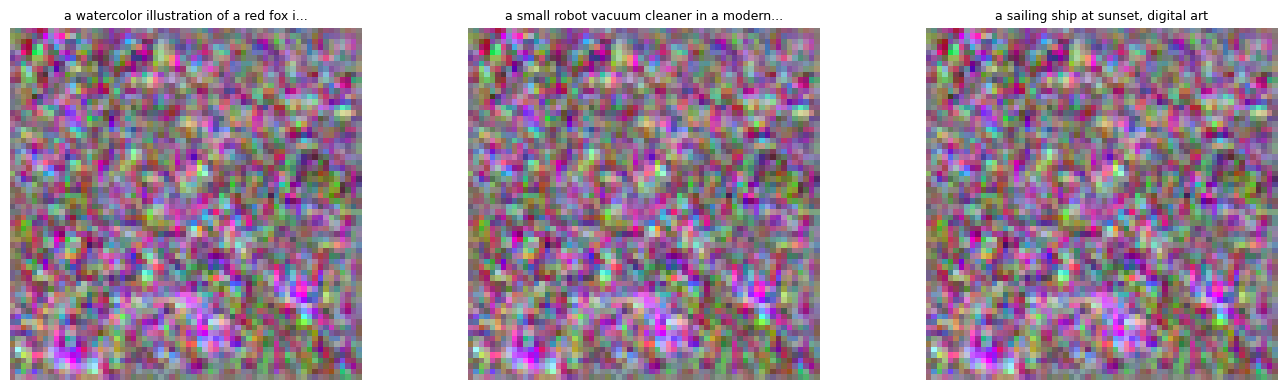

In [8]:

available_pairs = [(prompt, img) for prompt, img in zip(basic_prompts, generated_images) if img is not None]

if available_pairs:
    plt.figure(figsize=(14, 4))
    for idx, (prompt, image) in enumerate(available_pairs, start=1):
        ax = plt.subplot(1, len(available_pairs), idx)
        ax.imshow(image)
        ax.set_title(prompt[:40] + ("..." if len(prompt) > 40 else ""), fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("Изображения не сгенерированы – либо pipeline не загрузился, либо генерация была пропущена.")


## 6. Как prompt влияет на результат генерации

Возьмём одну и ту же базовую тему и опишем её по-разному:

- коротко;
- с указанием художественного стиля;
- с уточнением среды и деталей.

Это хороший аналог prompt engineering для мультимодальной генерации.

> **Напоминание:** с тестовой моделью все три изображения будут выглядеть  
> как шум разной формы – семантического влияния prompt здесь нет, потому что  
> веса модели не обучены различать текстовые условия.  
> В настоящей модели разные prompt-формулировки давали бы заметно разные картинки.


In [9]:

prompt_variants = [
    "a fox",
    "a realistic photo of a fox in snow",
    "a watercolor illustration of a red fox in snow under soft evening light",
]

variant_images: List[Optional[Image.Image]] = []
for idx, prompt in enumerate(prompt_variants):
    variant_images.append(generate_image(prompt=prompt, num_inference_steps=20, guidance_scale=7.0, seed=100 + idx))


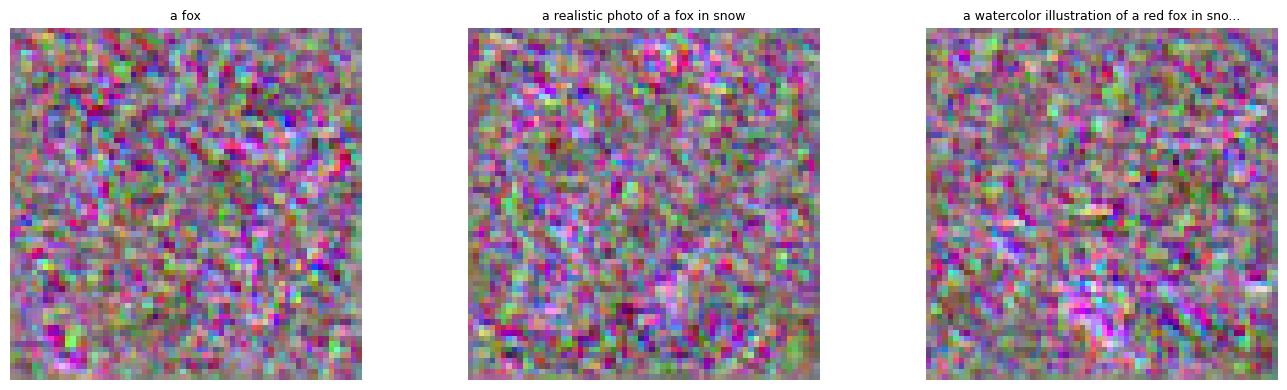

In [10]:

available_pairs = [(prompt, img) for prompt, img in zip(prompt_variants, variant_images) if img is not None]

if available_pairs:
    plt.figure(figsize=(14, 4))
    for idx, (prompt, image) in enumerate(available_pairs, start=1):
        ax = plt.subplot(1, len(available_pairs), idx)
        ax.imshow(image)
        ax.set_title(prompt[:45] + ("..." if len(prompt) > 45 else ""), fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("Сравнение prompt-вариантов пропущено: pipeline недоступен.")


## 7. Параметры генерации: `guidance_scale`, `num_inference_steps`, `negative_prompt`

В генеративных системах важен не только prompt, но и параметры процесса.

Интуитивно:

- `guidance_scale` – насколько сильно придерживаться текстового условия  
  (выше → сильнее следуем prompt, но может появляться пересатурация);
- `num_inference_steps` – сколько шагов денойзинга делать  
  (больше шагов → обычно лучше качество, но дольше генерация);
- `negative_prompt` – список признаков, которые желательно подавить в выходе.

Ниже сравниваем несколько конфигураций на одном и том же prompt.

> **Напоминание:** с тестовой моделью различия между конфигурациями не будут  
> визуально читаться – все три результата выглядят как шум.  
> В настоящей модели разница между `guidance_scale=4` и `guidance_scale=10`  
> была бы заметна: меньшее значение даёт более «свободные» изображения,  
> большее – точнее соответствует prompt, но с риском артефактов.


In [11]:

parameter_settings = [
    {"guidance_scale": 4.0, "num_inference_steps": 15, "negative_prompt": None},
    {"guidance_scale": 7.5, "num_inference_steps": 20, "negative_prompt": None},
    {"guidance_scale": 10.0, "num_inference_steps": 30, "negative_prompt": "blurry, low quality"},
]

parameter_prompt = "a futuristic city street at night, cinematic lighting"

parameter_images: List[Optional[Image.Image]] = []
for idx, params in enumerate(parameter_settings):
    image = generate_image(
        prompt=parameter_prompt,
        negative_prompt=params["negative_prompt"],
        guidance_scale=params["guidance_scale"],
        num_inference_steps=params["num_inference_steps"],
        seed=200 + idx,
    )
    parameter_images.append(image)


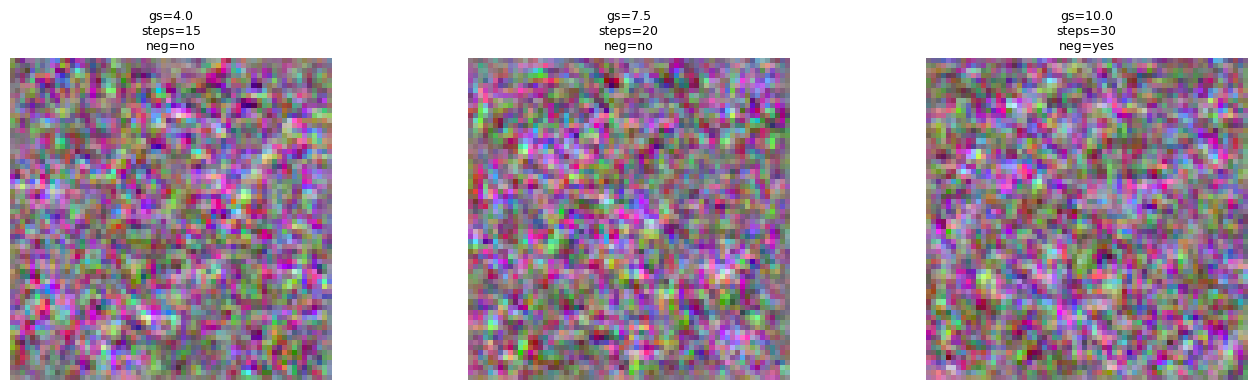

In [12]:

available_triplets = [
    (params, image)
    for params, image in zip(parameter_settings, parameter_images)
    if image is not None
]

if available_triplets:
    plt.figure(figsize=(14, 4))
    for idx, (params, image) in enumerate(available_triplets, start=1):
        ax = plt.subplot(1, len(available_triplets), idx)
        ax.imshow(image)
        title = (
            f"gs={params['guidance_scale']}\n"
            f"steps={params['num_inference_steps']}\n"
            f"neg={'yes' if params['negative_prompt'] else 'no'}"
        )
        ax.set_title(title, fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("Сравнение параметров пропущено: pipeline недоступен.")


## 8. Ограничения и риски генеративных мультимодальных моделей

На этом этапе важно сделать инженерно честный вывод.

Даже если генерация выглядит эффектно, у диффузионных моделей есть реальные ограничения:

- генерация ресурсоёмка по времени и памяти;
- результат не полностью детерминирован и зависит от seed;
- небольшие изменения prompt могут заметно менять выход;
- модель может давать артефакты и фактические несоответствия описанию;
- юридические и этические вопросы здесь особенно важны: авторские права, недостоверный синтез, злоупотребления.

То есть diffusion-модель – это не просто «красивый генератор картинок»,  
а полноценный инженерный компонент с вычислительной, правовой и качественной ценой.


## 9. Retrieval vs Generation: краткое сравнение

Соберём короткое сопоставление того, что мы сделали в S16-demo-01, S16-demo-02 и здесь.


In [13]:

comparison_df = pd.DataFrame(
    [
        {
            "approach": "CLIP matching / zero-shot classification",
            "input": "изображение + список текстовых описаний",
            "output": "наиболее подходящий текстовый класс",
            "best_use_case": "быстрый baseline без дообучения",
        },
        {
            "approach": "CLIP retrieval",
            "input": "текстовый запрос + галерея изображений",
            "output": "top-k наиболее близких изображений",
            "best_use_case": "поиск по существующей коллекции",
        },
        {
            "approach": "Diffusion generation",
            "input": "текстовый prompt",
            "output": "новое синтезированное изображение",
            "best_use_case": "создание нового визуального контента",
        },
    ]
)

comparison_df


,approach,input,output,best_use_case
0,CLIP matching / zero-shot classification,изображение + список текстовых описаний,наиболее подходящий текстовый класс,быстрый baseline без дообучения
1,CLIP retrieval,текстовый запрос + галерея изображений,top-k наиболее близких изображений,поиск по существующей коллекции
2,Diffusion generation,текстовый prompt,новое синтезированное изображение,создание нового визуального контента


## 10. Итоги

В этом ноутбуке мы:

- разобрали интуитивную идею диффузии;
- показали упрощённый прямой процесс через добавление шума;
- загрузили готовый diffusion pipeline;
- попробовали базовую text-to-image генерацию;
- сравнили влияние prompt и параметров;
- развели retrieval и generation как два разных мультимодальных сценария.

Именно так 16-й семинар закрывается в целостную картину:

- **CLIP** – про общее пространство признаков и поиск;
- **diffusion** – про генерацию нового изображения по условию.


## Задания для самостоятельной работы

1. Попробуйте другие prompt-шаблоны и сравните, как меняется результат генерации.
2. Проверьте влияние `guidance_scale` и `num_inference_steps` на качество и время работы.
3. Подберите примеры, где retrieval подходит лучше генерации, и наоборот.
4. Подумайте, какие риски возникают при использовании генеративных изображений в прикладной системе.
5. Если есть GPU и подходящая среда, попробуйте заменить demo-модель на более качественную diffusion-модель и сравнить результаты.
